In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

In [102]:
df_combined = pd.read_csv('data/All_features_all_tumours_with_metadata.csv')
df_combined

,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,Model,GLbins,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,basal,8,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,basal,8,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,basal,8,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,basal,8,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,basal,8,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,basal,256,770,MB
2264,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,basal,256,800,MB
2265,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,basal,256,820,MB
2266,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,basal,256,840,MB


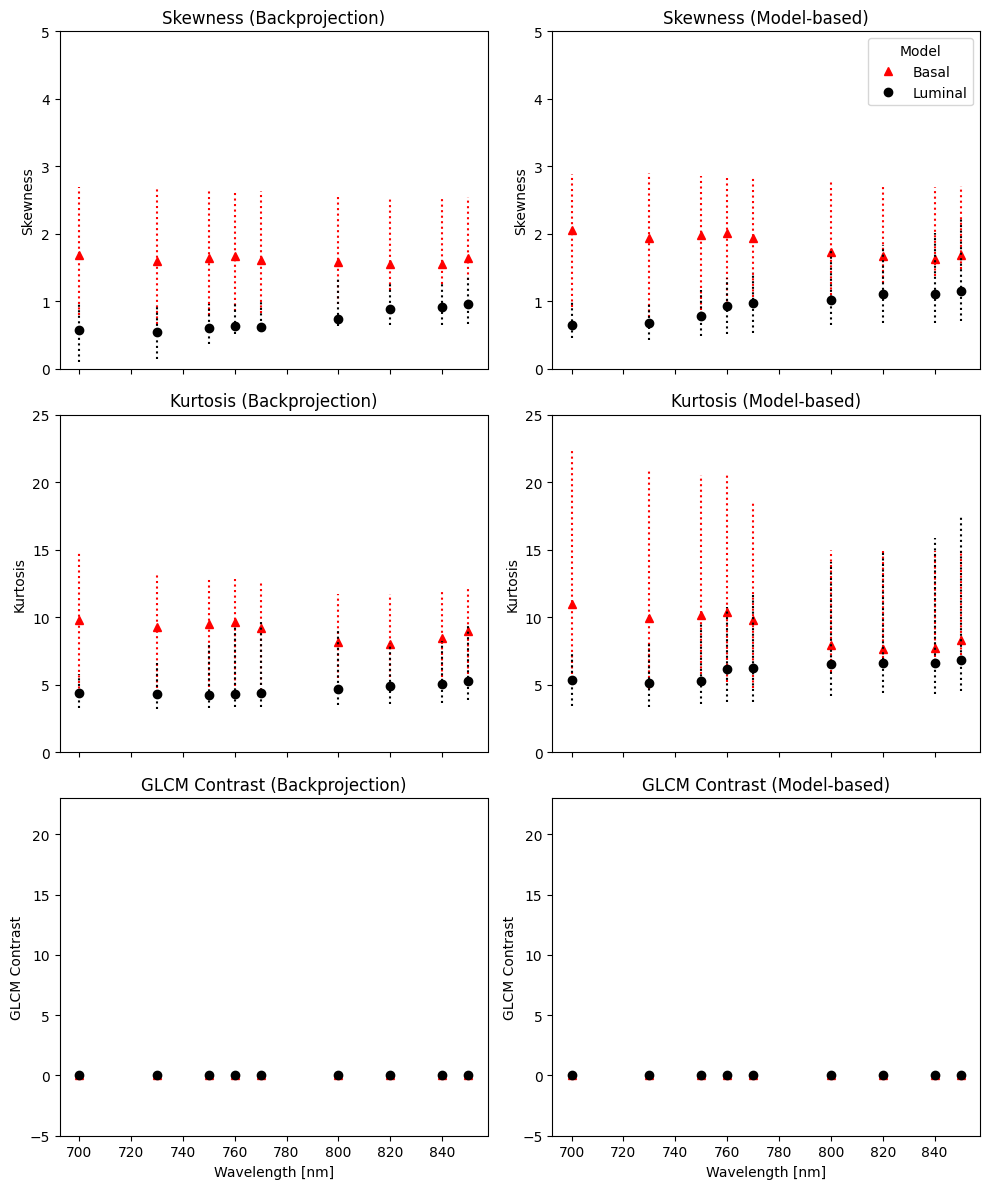

In [106]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define parameters
features = ["FO Skewness", "FO Kurtosis", "GLCM Contrast"]
titles = ["Skewness", "Kurtosis", "GLCM Contrast"]
y_lims = [(0, 5), (0, 25), (-5, 23)]
recons = ["BP", "MB"]
colors = {"basal": "red", "luminal": "black"}
markers = {"basal": "^", "luminal": "o"}

# Create 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True)

for col, recon in enumerate(recons):
    for row, feature in enumerate(features):
        ax = axs[row, col]
        df_sub = df_combined[df_combined["Reconstruction"] == recon]

        for model in ["basal", "luminal"]:
            df_model = df_sub[df_sub["Model"] == model]
            grouped = df_model.groupby("Wavelength")[feature]
            med = grouped.median()
            iqr_min = grouped.quantile(0.25)
            iqr_max = grouped.quantile(0.75)

            wl = med.index.values
            ax.plot(wl, med.values, markers[model], color=colors[model],
                    label=model.capitalize() if row == 0 else "", markersize=6)
            ax.vlines(wl, iqr_min.values, iqr_max.values,
                      color=colors[model], linestyle='dotted')

        ax.set_title(f"{titles[row]} ({'Backprojection' if recon == 'BP' else 'Model-based'})")
        ax.set_ylim(y_lims[row])
        if row == 2:
            ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel(titles[row])

        if row == 0 and col == 1:
            ax.legend(title="Model", loc="upper right")

plt.tight_layout()
# Save the figure
plt.savefig("plots/IQR_plots_corrected.png", dpi=300, bbox_inches='tight')
plt.show()


In [104]:
df_combined_uncorr = pd.read_csv('data/All_features_uncorrected_all_tumours_with_metadata.csv')
df_combined_uncorr["Model"] = df_combined_uncorr["Model"].str.lower()
df_combined_uncorr


,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,PatientName,Model,GLbins,Wavelength,Reconstruction
0,69.142880,290.878683,4.448008e+09,4.636961,99.644165,23.988499,1506.465942,80.712806,167.184233,136.090408,...,0.649439,0.000213,9857.477189,0.011104,5.653971,10,basal,128,700,BP
1,68.959734,246.576346,3.275936e+09,4.593670,80.613131,24.513340,1244.968140,64.953736,148.365253,123.751446,...,0.613472,0.000216,9090.936807,0.010184,5.597988,10,basal,128,730,BP
2,70.308770,265.578290,3.766853e+09,4.614533,87.411236,24.715534,1360.987915,71.373395,156.751060,129.119141,...,0.680027,0.000209,9797.183512,0.011258,5.547308,10,basal,128,750,BP
3,69.735306,273.831262,4.000455e+09,4.573273,91.426805,24.677900,1426.273926,74.664145,160.247312,131.045944,...,0.648330,0.000207,9433.435006,0.010615,5.514328,10,basal,128,760,BP
4,68.767374,252.913724,3.433929e+09,4.613481,83.389416,24.597626,1282.152344,67.249362,150.974229,125.121998,...,0.631979,0.000218,9379.392808,0.010543,5.812234,10,basal,128,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,992.082990,4457.898047,1.070236e+12,1.369536,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,2080.059937,...,286.869851,0.000104,6.681988,0.002877,0.005507,98,basal,8,770,MB
2264,851.154541,4067.293140,8.697697e+11,1.501392,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,1894.330383,...,310.723250,0.000111,6.738676,0.003780,0.005968,98,basal,8,800,MB
2265,838.989789,4029.269922,8.527069e+11,1.469264,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,1876.432617,...,308.923560,0.000117,6.501626,0.003656,0.006386,98,basal,8,820,MB
2266,878.749854,4083.819263,8.834429e+11,1.551741,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,1926.486694,...,306.856707,0.000115,6.690178,0.004198,0.005954,98,basal,8,840,MB


Wavelength
700    1.684451
730    1.602398
750    1.647475
760    1.678718
770    1.609256
800    1.578938
820    1.551177
840    1.553148
850    1.636307
Name: original_firstorder_Skewness, dtype: float64
Wavelength
700    0.570714
730    0.546737
750    0.607730
760    0.628635
770    0.620756
800    0.740811
820    0.886133
840    0.920323
850    0.954264
Name: original_firstorder_Skewness, dtype: float64
Wavelength
700    9.765710
730    9.291542
750    9.520802
760    9.655328
770    9.202042
800    8.160001
820    7.994226
840    8.436775
850    9.016854
Name: original_firstorder_Kurtosis, dtype: float64
Wavelength
700    4.377787
730    4.336852
750    4.219966
760    4.342363
770    4.362771
800    4.714880
820    4.874661
840    5.055102
850    5.272895
Name: original_firstorder_Kurtosis, dtype: float64
Wavelength
700    2.592639
730    2.586182
750    2.631760
760    2.611220
770    2.627296
800    2.659723
820    2.845859
840    2.822348
850    2.812088
Name: original_glcm_C

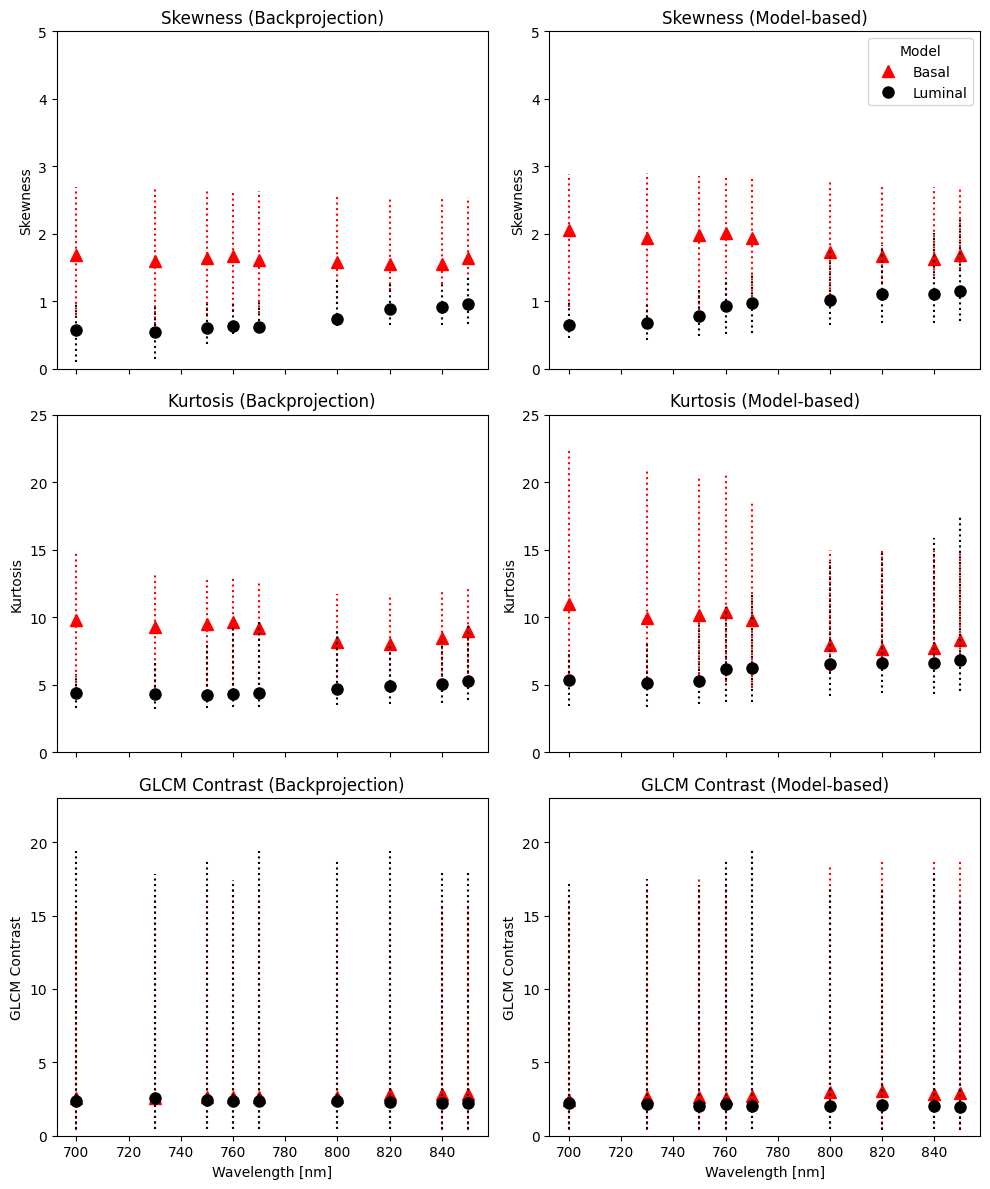

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define parameters
features = ["original_firstorder_Skewness", "original_firstorder_Kurtosis", "original_glcm_Contrast"]
titles = ["Skewness", "Kurtosis", "GLCM Contrast"]
y_lims = [(0, 5), (0, 25), (0, 23)]
recons = ["BP", "MB"]
colors = {"basal": "red", "luminal": "black"}
markers = {"basal": "^", "luminal": "o"}

# Create 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True)

for col, recon in enumerate(recons):
    for row, feature in enumerate(features):
        ax = axs[row, col]
        df_sub = df_combined_uncorr[df_combined_uncorr["Reconstruction"] == recon]

        for model in ["basal", "luminal"]:
            df_model = df_sub[df_sub["Model"] == model]
            grouped = df_model.groupby("Wavelength")[feature]
            med = grouped.median()
            iqr_min = grouped.quantile(0.25)
            iqr_max = grouped.quantile(0.75)
            print(med)

            wl = med.index.values
            ax.plot(wl, med.values, markers[model], color=colors[model],
                    label=model.capitalize() if row == 0 else "", markersize=8)
            ax.vlines(wl, iqr_min.values, iqr_max.values,
                      color=colors[model], linestyle='dotted')

        ax.set_title(f"{titles[row]} ({'Backprojection' if recon == 'BP' else 'Model-based'})")
        ax.set_ylim(y_lims[row])
        if row == 2:
            ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel(titles[row])

        if row == 0 and col == 1:
            ax.legend(title="Model", loc="upper right")

plt.tight_layout()
# Save the figure
plt.savefig("plots/IQR_plots_uncorrected.png", dpi=300, bbox_inches='tight')
plt.show()


In [92]:
print(df_combined_uncorr.shape)
print(df_combined_uncorr["Reconstruction"].unique())
print(df_combined_uncorr["Model"].unique())


(2160, 98)
['BP' 'MB']
['Basal' 'Luminal']
